**Importing libraries**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import shap


**Loading dataset**

In [2]:
data = pd.read_csv("/content/Website Phishing.csv")
print(data.head())

   SFH  popUpWidnow  SSLfinal_State  Request_URL  URL_of_Anchor  web_traffic  \
0    1           -1               1           -1             -1            1   
1   -1           -1              -1           -1             -1            0   
2    1           -1               0            0             -1            0   
3    1            0               1           -1             -1            0   
4   -1           -1               1           -1              0            0   

   URL_Length  age_of_domain  having_IP_Address  Result  
0           1              1                  0       0  
1           1              1                  1       1  
2          -1              1                  0       1  
3           1              1                  0       0  
4          -1              1                  0       1  


**Checking shape and columns of data**

In [3]:
print("Dataset shape:", data.shape)
print("Columns:", data.columns)

Dataset shape: (1353, 10)
Columns: Index(['SFH', 'popUpWidnow', 'SSLfinal_State', 'Request_URL', 'URL_of_Anchor',
       'web_traffic', 'URL_Length', 'age_of_domain', 'having_IP_Address',
       'Result'],
      dtype='object')


**Checking class distribution**

In [4]:
print(data['Result'].value_counts())

Result
-1    702
 1    548
 0    103
Name: count, dtype: int64


**Checking missing values**

In [5]:
print("missing values:")
print(data.isnull().sum())

missing values:
SFH                  0
popUpWidnow          0
SSLfinal_State       0
Request_URL          0
URL_of_Anchor        0
web_traffic          0
URL_Length           0
age_of_domain        0
having_IP_Address    0
Result               0
dtype: int64


**Descriptive Statistics**

In [6]:
print("Descriptive Statistics:")
data.describe()

Descriptive Statistics:


,SFH,popUpWidnow,SSLfinal_State,Request_URL,URL_of_Anchor,web_traffic,URL_Length,age_of_domain,having_IP_Address,Result
count,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000
mean,0.237990,-0.258684,0.327421,-0.223208,-0.025129,0.000000,-0.053215,0.219512,0.114560,-0.113821
std,0.916389,0.679072,0.822193,0.799682,0.936262,0.806776,0.762552,0.975970,0.318608,0.954773
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000
25%,-1.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-1.000000
75%,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Plotting class distribution**

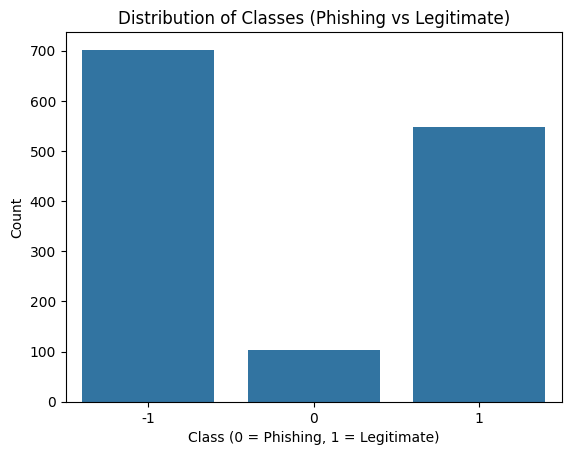

In [7]:
sns.countplot(x='Result', data=data)

plt.title("Distribution of Classes (Phishing vs Legitimate)")
plt.xlabel("Class (0 = Phishing, 1 = Legitimate)")
plt.ylabel("Count")

plt.show()

**Distribution of URL Length**

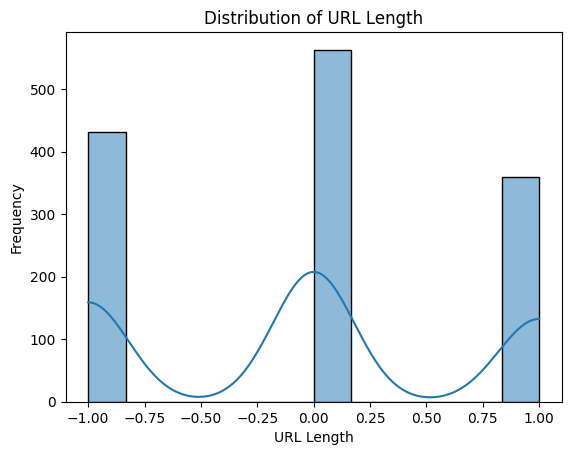

In [8]:
sns.histplot(data['URL_Length'], kde=True)

plt.title("Distribution of URL Length")
plt.xlabel("URL Length")
plt.ylabel("Frequency")

plt.show()

**URL Length vs Class**

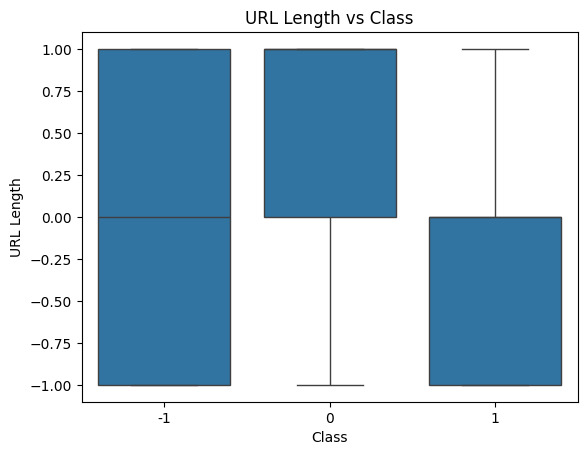

In [9]:
sns.boxplot(x='Result', y='URL_Length', data=data)

plt.title("URL Length vs Class")
plt.xlabel("Class")
plt.ylabel("URL Length")

plt.show()

**Correlation Heatmap**

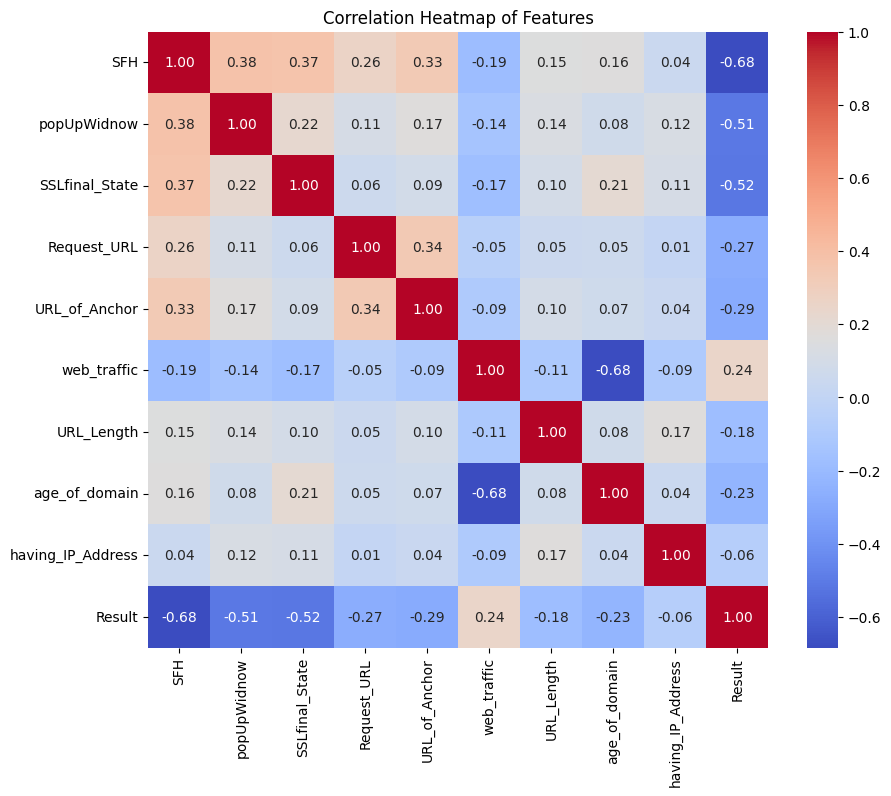

In [10]:
corr = data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap of Features")
plt.show()

**Converting to Binary Classification**

In [11]:
data['Result'] = data['Result'].replace({-1:0, 0:0, 1:1})

print(data['Result'].value_counts())

Result
0    805
1    548
Name: count, dtype: int64


**Feature & Label Splitting**

In [12]:
X = data.drop('Result', axis=1)
y = data['Result']

**Train-Test Splitting**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1082, 9)
Test size: (271, 9)


**Feature Scaling**

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Building ANN Model**

In [15]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

**Training Model**

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6763 - loss: 0.6440 - val_accuracy: 0.8157 - val_loss: 0.5770
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8012 - loss: 0.5043 - val_accuracy: 0.8479 - val_loss: 0.3992
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8462 - loss: 0.3718 - val_accuracy: 0.8710 - val_loss: 0.3165
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8798 - loss: 0.2890 - val_accuracy: 0.8618 - val_loss: 0.3072
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8751 - loss: 0.2913 - val_accuracy: 0.8618 - val_loss: 0.3019
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8809 - loss: 0.2841 - val_accuracy: 0.8479 - val_loss: 0.3060
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8855 - loss: 0.2624 - val_accuracy: 0.8571 - val_loss: 0.3045
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8879 - loss: 0.2630 - val_accuracy: 0.8525 - val_loss

**Plotting Training Graphs**

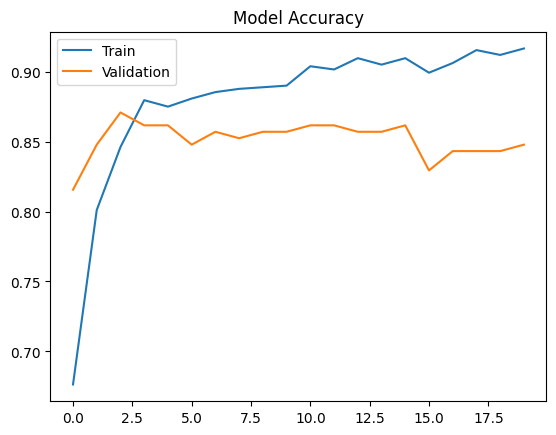

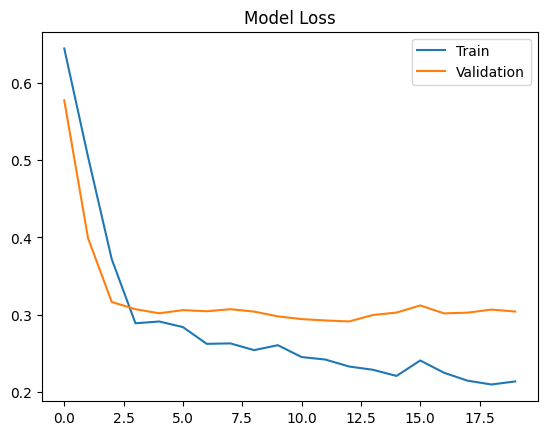

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

**Model Evaluation**

In [18]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       157
           1       0.82      0.91      0.86       114

    accuracy                           0.88       271
   macro avg       0.87      0.88      0.88       271
weighted avg       0.88      0.88      0.88       271



**Confusion Matrix**

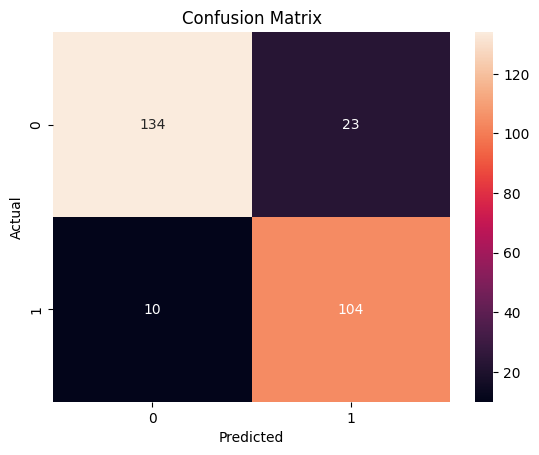

In [19]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**SHAP Explainability**

ExactExplainer explainer: 101it [00:10,  1.70it/s]                        


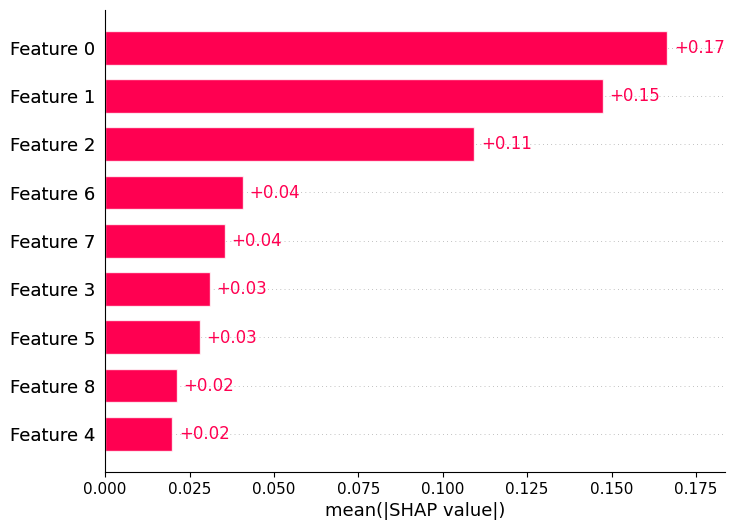

In [20]:
explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

**Feature Importance Plot**

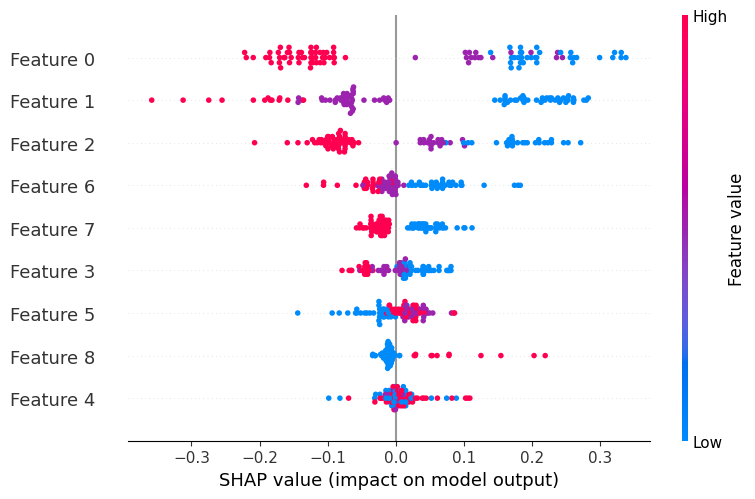

In [21]:
shap.summary_plot(shap_values, X_test[:100])